# Attack-Surface Verification — D4v2 v8 Runs

Per-run diagnosis of three reward-hacking attack surfaces:
1. **Length bias** (Suite L) — is judge systematically favoring longer plans?
2. **Train-eval judge gap** (Suite J) — do GPT-OSS-120B and Opus diverge as policy drifts?
3. **Single-signal saturation** (Suite S) — is one signal (G4/G6) dominating and saturating?

All core experiments offline on `buffer.jsonl`. Optional L4/J4 use Opus (~50 calls total). Plan: `.claude/plans/generic-questing-dijkstra.md`.

**Decision rules are pre-registered** — every metric has a threshold defined before running.

In [1]:
import json
import sys
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr

REPO_ROOT = Path('/home/silas/co-scientist-project')
sys.path.insert(0, str(REPO_ROOT / 'src'))

from co_scientist.shared.grant_signal_reward import SIGNAL_WEIGHTS as V7_WEIGHTS
from co_scientist.shared.grant_rubric_v8 import SIGNAL_WEIGHTS as V8_WEIGHTS

V7_KEYS = set(V7_WEIGHTS.keys())
V8_KEYS = set(V8_WEIGHTS.keys())

def infer_rubric(signal_vector: dict) -> tuple[str, dict]:
    keys = set(signal_vector.keys())
    v8_overlap = len(keys & V8_KEYS) / max(len(V8_KEYS), 1)
    v7_overlap = len(keys & V7_KEYS) / max(len(V7_KEYS), 1)
    if v8_overlap >= 0.9 and 'G3_technical_evidence' not in keys:
        return 'v8', V8_WEIGHTS
    return 'v7', V7_WEIGHTS

def normalize_score(s, smax=5):
    if s is None: return 0.0
    return min(max((s - 1) / (smax - 1), 0.0), 1.0)

def aggregate_with_weights(signal_vector: dict, weights: dict, clip_at: Optional[int] = None) -> float:
    total = 0.0
    for sid, w in weights.items():
        raw = signal_vector.get(sid)
        if clip_at is not None and raw is not None:
            raw = min(raw, clip_at)
        total += w * normalize_score(raw)
    return total

print(f'V7 weights: {len(V7_WEIGHTS)} signals, sum={sum(V7_WEIGHTS.values()):.3f}')
print(f'V8 weights: {len(V8_WEIGHTS)} signals, sum={sum(V8_WEIGHTS.values()):.3f}')

V7 weights: 12 signals, sum=1.000
V8 weights: 10 signals, sum=1.000


In [2]:
# ============================================================================
# Load all runs. For Phase 0 we also load C-series (v7) as pre-registered baseline.
# ============================================================================
RUNS = {
    # v8 runs (primary targets)
    'B4_v8':      REPO_ROOT / 'projects/grant_proposal_v2/runs/2026_04_22_v8_foundopt_B4',
    'MAIN_v8_C3': REPO_ROOT / 'projects/grant_proposal_v2/runs/2026_04_22_v8_foundopt_MAIN_C3',
    'MAIN_v8_C4': REPO_ROOT / 'projects/grant_proposal_v2/runs/2026_04_22_v8_foundopt_MAIN_C4',
    # v7 C-series (pre-registered baseline, already complete)
    'B4_v7':      REPO_ROOT / 'projects/grant_proposal/runs/2026_04_22_sdpo_C2_B4_scores_only',
    'MAIN_v7_C3': REPO_ROOT / 'projects/grant_proposal/runs/2026_04_22_sdpo_C3_sdpo_scores_only',
    'MAIN_v7_C4': REPO_ROOT / 'projects/grant_proposal/runs/2026_04_22_sdpo_C4_aggregate_scores_only',
}

def load_run(run_dir: Path) -> pd.DataFrame:
    buffer_path = run_dir / 'buffer.jsonl'
    if not buffer_path.exists():
        return pd.DataFrame()
    rows = []
    with open(buffer_path) as f:
        for line in f:
            try:
                r = json.loads(line)
            except json.JSONDecodeError:
                continue
            row = {
                'iteration': r.get('iteration'),
                'entry_type': r.get('entry_type'),
                'word_count': r.get('word_count'),
                'aggregate_reward': r.get('aggregate_reward'),
                'hard_gate_passed': r.get('hard_gate_passed'),
                'parent_idx': r.get('parent_idx'),
                'delta_reward': r.get('delta_reward'),
            }
            sv = r.get('signal_vector', {}) or {}
            for sid, score in sv.items():
                row[f'sig_{sid}'] = score
            pr = r.get('per_repeat_scores', []) or []
            if pr:
                repeats_by_sig = {}
                for rep in pr:
                    for k, v in (rep or {}).items():
                        repeats_by_sig.setdefault(k, []).append(v)
                for k, vs in repeats_by_sig.items():
                    if len(vs) > 1:
                        row[f'std_{k}'] = float(np.std(vs))
            rows.append(row)
    return pd.DataFrame(rows)

dfs = {}
for name, run_dir in RUNS.items():
    df = load_run(run_dir)
    if df.empty:
        print(f'  {name}: NO DATA (dir missing or buffer empty)')
        continue
    rubric, weights = infer_rubric({k.replace('sig_', ''): 1 for k in df.columns if k.startswith('sig_')})
    dfs[name] = {'df': df, 'rubric': rubric, 'weights': weights}
    print(f'  {name}: {len(df)} rows, iters {df.iteration.min()}-{df.iteration.max()}, rubric={rubric}')

print(f'\nLoaded {len(dfs)} runs.')

  B4_v8: 108 rows, iters 0-13, rubric=v8
  MAIN_v8_C3: 116 rows, iters 0-14, rubric=v8
  MAIN_v8_C4: 115 rows, iters 0-14, rubric=v8
  B4_v7: 196 rows, iters 0-24, rubric=v7
  MAIN_v7_C3: 275 rows, iters 0-34, rubric=v7
  MAIN_v7_C4: 275 rows, iters 0-34, rubric=v7

Loaded 6 runs.


## Suite L — Length Bias

| Exp | Metric | Threshold (confirmed if) |
|---|---|---|
| L1 | Spearman ρ(length, agg) | >0.5 or any ρ(length, G_i) > 0.6 |
| L2 | MAIN median length growth | >20% while B4 grows <10% |
| L3 | R²(Opus ~ log len) vs R²(GPT-OSS ~ log len) | GPT-OSS R² - Opus R² > 0.2 |
| L4 | Length-matched Opus pairing | MAIN win rate ≤ 50% |

In [3]:
# L1. Length-score correlations (free, offline)
l1_rows = []
for name, info in dfs.items():
    df = info['df']
    if df.empty or df['word_count'].isna().all():
        continue
    mask = df['word_count'].notna() & df['aggregate_reward'].notna()
    rho_agg, p_agg = spearmanr(df.loc[mask, 'word_count'], df.loc[mask, 'aggregate_reward'])
    row = {'run': name, 'rho_len_aggregate': rho_agg, 'n': mask.sum()}
    for sid in info['weights'].keys():
        col = f'sig_{sid}'
        if col in df.columns:
            m2 = mask & df[col].notna()
            if m2.sum() > 5:
                rho, _ = spearmanr(df.loc[m2, 'word_count'], df.loc[m2, col])
                row[f'rho_len_{sid.split("_")[0]}'] = rho
    l1_rows.append(row)

l1 = pd.DataFrame(l1_rows).set_index('run')
pd.options.display.float_format = '{:.3f}'.format
print('L1 — Spearman ρ(word_count, <score>):')
display(l1)

# Decision: flag runs where any correlation exceeds threshold
l1_verdict = {}
for run, row in l1.iterrows():
    agg_flag = abs(row.get('rho_len_aggregate', 0)) > 0.5
    sig_flags = [abs(v) > 0.6 for k, v in row.items() if k.startswith('rho_len_G') and pd.notna(v)]
    l1_verdict[run] = agg_flag or any(sig_flags)
print('\nL1 verdict (confirmed?):', l1_verdict)

L1 — Spearman ρ(word_count, <score>):


/tmp/ipykernel_363642/1901604428.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(df.loc[m2, 'word_count'], df.loc[m2, col])


,rho_len_aggregate,n,rho_len_G1,rho_len_G2,rho_len_G4,rho_len_G6,rho_len_G8,rho_len_G9,rho_len_G10,rho_len_G11,rho_len_G12,rho_len_G13,rho_len_G3,rho_len_G5
run,,,,,,,,,,,,,,
B4_v8,0.832,108,-0.374,-0.136,0.324,0.198,0.545,0.476,0.067,0.720,0.778,0.764,NaN,NaN
MAIN_v8_C3,0.613,116,-0.389,-0.335,-0.090,-0.053,0.254,0.410,0.092,0.673,0.779,0.665,NaN,NaN
MAIN_v8_C4,0.689,115,-0.395,-0.270,0.117,0.075,0.264,0.043,0.148,0.599,0.819,0.751,NaN,NaN
B4_v7,0.720,196,-0.579,0.318,0.003,0.598,0.434,0.586,0.105,0.583,0.798,0.743,0.769,NaN
MAIN_v7_C3,0.557,275,-0.146,0.117,0.035,0.329,0.275,0.288,0.025,0.500,0.575,0.445,0.646,0.005
MAIN_v7_C4,0.693,275,-0.415,0.319,0.063,0.604,0.562,0.665,0.102,0.617,0.711,0.762,0.727,NaN



L1 verdict (confirmed?): {'B4_v8': np.True_, 'MAIN_v8_C3': np.True_, 'MAIN_v8_C4': np.True_, 'B4_v7': np.True_, 'MAIN_v7_C3': np.True_, 'MAIN_v7_C4': np.True_}


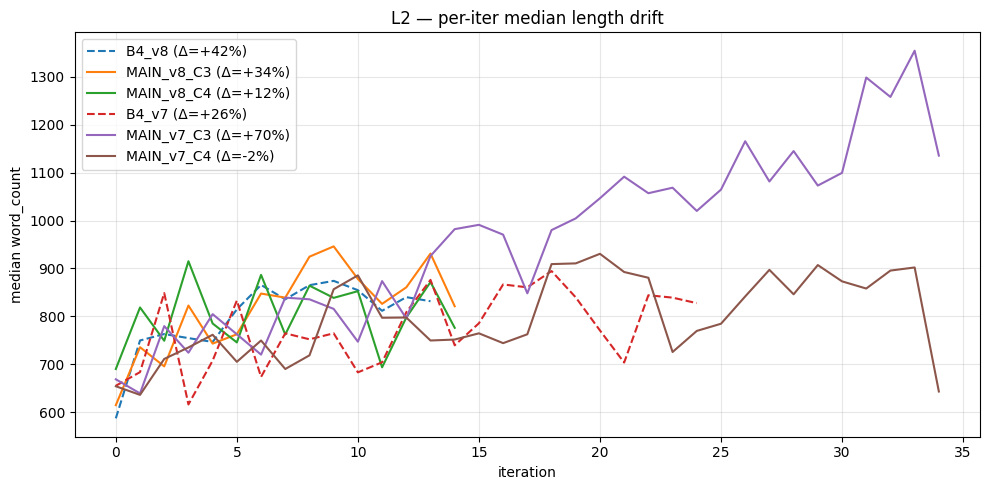


L2 — median length growth iter[0] → iter[final]:
  B4_v8: +41.7%
  MAIN_v8_C3: +33.6%
  MAIN_v8_C4: +12.5%
  B4_v7: +26.3%
  MAIN_v7_C3: +69.9%
  MAIN_v7_C4: -1.7%
L2 verdict (confirmed for MAIN runs?): {'B4_v8': False, 'MAIN_v8_C3': np.False_, 'MAIN_v8_C4': np.False_, 'B4_v7': False, 'MAIN_v7_C3': np.False_, 'MAIN_v7_C4': np.False_}


In [4]:
# L2. Per-iter length drift
fig, ax = plt.subplots(figsize=(10, 5))
l2_growth = {}
for name, info in dfs.items():
    df = info['df']
    if df.empty: continue
    g = df.groupby('iteration')['word_count'].median()
    if len(g) < 2: continue
    growth = (g.iloc[-1] - g.iloc[0]) / max(g.iloc[0], 1)
    l2_growth[name] = growth
    ls = '--' if 'B4' in name else '-'
    ax.plot(g.index, g.values, label=f'{name} (Δ={growth:+.0%})', linestyle=ls)
ax.set_xlabel('iteration'); ax.set_ylabel('median word_count'); ax.legend(); ax.set_title('L2 — per-iter median length drift')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print('\nL2 — median length growth iter[0] → iter[final]:')
for k, v in l2_growth.items(): print(f'  {k}: {v:+.1%}')

l2_verdict = {}
for run, g in l2_growth.items():
    if 'MAIN' in run:
        b4_name = run.replace('MAIN_', 'B4_').rsplit('_', 1)[0]
        b4_keys = [k for k in l2_growth if k.startswith('B4') and (run.split('_')[1] in k)]
        b4_growth = l2_growth[b4_keys[0]] if b4_keys else 0
        l2_verdict[run] = (g > 0.20) and (b4_growth < 0.10)
    else:
        l2_verdict[run] = False
print('L2 verdict (confirmed for MAIN runs?):', l2_verdict)

In [5]:
# L3. ODIN-style length-head regression.
# Depends on Opus depth audits. If depth_audit_mid.jsonl not present, reports NA.
def load_audits(run_dir):
    out = []
    for fname in ['depth_audit_mid.jsonl', 'opus_eval_log.jsonl']:
        fp = run_dir / fname
        if fp.exists():
            with open(fp) as f:
                for line in f:
                    try: out.append(json.loads(line))
                    except json.JSONDecodeError: pass
    return out

l3_rows = []
for name, info in dfs.items():
    audits = load_audits(RUNS[name])
    if not audits:
        l3_rows.append({'run': name, 'n_audits': 0, 'R2_opus': None, 'R2_gptoss': None, 'delta_R2': None})
        continue
    # Align audits with buffer by iteration
    df = info['df']
    merged = []
    for a in audits:
        it = a.get('iteration', a.get('iter'))
        opus_tot = a.get('total', a.get('depth_total'))
        if it is None or opus_tot is None: continue
        subs = df[df['iteration'] == it]
        if subs.empty: continue
        best = subs.loc[subs['aggregate_reward'].idxmax()]
        merged.append({'iter': it, 'wc': best['word_count'], 'gptoss': best['aggregate_reward'], 'opus': opus_tot})
    if len(merged) < 4:
        l3_rows.append({'run': name, 'n_audits': len(merged), 'R2_opus': None, 'R2_gptoss': None, 'delta_R2': None})
        continue
    mdf = pd.DataFrame(merged)
    logwc = np.log(mdf['wc'].values)
    def r2(y): x = logwc; A = np.vstack([x, np.ones_like(x)]).T; b, _, _, _ = np.linalg.lstsq(A, y, rcond=None); yhat = A @ b; ss_res = ((y - yhat) ** 2).sum(); ss_tot = ((y - y.mean()) ** 2).sum(); return 1 - ss_res / ss_tot if ss_tot > 0 else 0
    r2_op = r2(mdf['opus'].values); r2_q = r2(mdf['gptoss'].values)
    l3_rows.append({'run': name, 'n_audits': len(merged), 'R2_opus': r2_op, 'R2_gptoss': r2_q, 'delta_R2': r2_q - r2_op})

l3 = pd.DataFrame(l3_rows).set_index('run')
print('L3 — log(length) as predictor of Opus vs GPT-OSS:')
display(l3)
l3_verdict = {r: (row['delta_R2'] > 0.2) if pd.notna(row['delta_R2']) else None for r, row in l3.iterrows()}
print('L3 verdict:', l3_verdict)

L3 — log(length) as predictor of Opus vs GPT-OSS:


,n_audits,R2_opus,R2_gptoss,delta_R2
run,,,,
B4_v8,3,None,None,None
MAIN_v8_C3,3,None,None,None
MAIN_v8_C4,3,None,None,None
B4_v7,0,None,None,None
MAIN_v7_C3,0,None,None,None
MAIN_v7_C4,0,None,None,None


L3 verdict: {'B4_v8': None, 'MAIN_v8_C3': None, 'MAIN_v8_C4': None, 'B4_v7': None, 'MAIN_v7_C3': None, 'MAIN_v7_C4': None}


In [6]:
# L4 (OPTIONAL, ~20 Opus calls): length-matched B4 vs MAIN pairing.
# Skeleton only — populate at Phase 3 if L1/L2/L3 flag length bias.
print('L4 stub — run only after core suites confirm length bias candidates.')
print('Implementation: extract top-10 final-iter best plans from B4 and MAIN,')
print('pair within ±15% word_count, call opus_depth_audit on each pair, count MAIN win rate.')

L4 stub — run only after core suites confirm length bias candidates.
Implementation: extract top-10 final-iter best plans from B4 and MAIN,
pair within ±15% word_count, call opus_depth_audit on each pair, count MAIN win rate.


## Suite J — Train-Eval Judge Gap

| Exp | Metric | Threshold (confirmed if) |
|---|---|---|
| J1 | Δρ(iter_early → iter_late) | drop ≥ 0.15 in any MAIN |
| J2 | 95% CI(ρ_early) vs CI(ρ_late) | non-overlapping |
| J3 | top-5 set intersection | drops from ≥4 to ≤2 |
| J4 | GPT-OSS paraphrase drop − Opus drop | ≥ 0.10 (GPT-OSS fingerprinted wording) |

In [7]:
# J1/J2/J3. All depend on Opus audit data merged with buffer.
def merged_audits(name):
    info = dfs.get(name); audits = load_audits(RUNS[name])
    if not info or not audits: return pd.DataFrame()
    df = info['df']
    rows = []
    for a in audits:
        it = a.get('iteration', a.get('iter')); opus_tot = a.get('total', a.get('depth_total'))
        if it is None or opus_tot is None: continue
        subs = df[df['iteration'] == it]
        if subs.empty: continue
        best = subs.loc[subs['aggregate_reward'].idxmax()]
        rows.append({'iter': it, 'gptoss': best['aggregate_reward'], 'opus': opus_tot, 'wc': best['word_count']})
    return pd.DataFrame(rows).sort_values('iter')

# J1
j1_rows = []
for name in dfs:
    m = merged_audits(name)
    if len(m) < 4:
        j1_rows.append({'run': name, 'n': len(m), 'rho_early': None, 'rho_late': None, 'delta_rho': None})
        continue
    mid = len(m) // 2
    rho_early, _ = spearmanr(m.iloc[:mid]['gptoss'], m.iloc[:mid]['opus']) if mid >= 2 else (None, None)
    rho_late, _ = spearmanr(m.iloc[mid:]['gptoss'], m.iloc[mid:]['opus']) if len(m) - mid >= 2 else (None, None)
    j1_rows.append({'run': name, 'n': len(m), 'rho_early': rho_early, 'rho_late': rho_late,
                    'delta_rho': (rho_early - rho_late) if rho_early and rho_late else None})
j1 = pd.DataFrame(j1_rows).set_index('run')
print('J1 — Spearman ρ(GPT-OSS, Opus) early vs late half of audits:')
display(j1)
j1_verdict = {r: (row['delta_rho'] >= 0.15) if pd.notna(row['delta_rho']) else None for r, row in j1.iterrows()}
print('J1 verdict:', j1_verdict)

J1 — Spearman ρ(GPT-OSS, Opus) early vs late half of audits:


,n,rho_early,rho_late,delta_rho
run,,,,
B4_v8,3,None,None,None
MAIN_v8_C3,3,None,None,None
MAIN_v8_C4,3,None,None,None
B4_v7,0,None,None,None
MAIN_v7_C3,0,None,None,None
MAIN_v7_C4,0,None,None,None


J1 verdict: {'B4_v8': None, 'MAIN_v8_C3': None, 'MAIN_v8_C4': None, 'B4_v7': None, 'MAIN_v7_C3': None, 'MAIN_v7_C4': None}


In [8]:
# J2. Bootstrap CI on ρ for each run. Uses merged_audits from J1.
def bootstrap_rho(x, y, n=1000, seed=0):
    rng = np.random.default_rng(seed); n_obs = len(x); rhos = []
    for _ in range(n):
        idx = rng.integers(0, n_obs, n_obs)
        if len(set(x[idx])) > 1 and len(set(y[idx])) > 1:
            rho, _ = spearmanr(x[idx], y[idx])
            rhos.append(rho)
    return np.array(rhos) if rhos else np.array([0])

j2_rows = []
for name in dfs:
    m = merged_audits(name)
    if len(m) < 6:
        j2_rows.append({'run': name, 'ci_early': None, 'ci_late': None, 'non_overlap': None})
        continue
    mid = len(m) // 2
    bs_e = bootstrap_rho(m.iloc[:mid]['gptoss'].values, m.iloc[:mid]['opus'].values)
    bs_l = bootstrap_rho(m.iloc[mid:]['gptoss'].values, m.iloc[mid:]['opus'].values)
    ci_e = (np.percentile(bs_e, 2.5), np.percentile(bs_e, 97.5))
    ci_l = (np.percentile(bs_l, 2.5), np.percentile(bs_l, 97.5))
    non_overlap = (ci_e[0] > ci_l[1]) or (ci_l[0] > ci_e[1])
    j2_rows.append({'run': name, 'ci_early': f'[{ci_e[0]:.2f}, {ci_e[1]:.2f}]', 'ci_late': f'[{ci_l[0]:.2f}, {ci_l[1]:.2f}]', 'non_overlap': non_overlap})
j2 = pd.DataFrame(j2_rows).set_index('run')
print('J2 — Bootstrap 95% CIs on ρ:')
display(j2)
j2_verdict = {r: row['non_overlap'] for r, row in j2.iterrows()}
print('J2 verdict:', j2_verdict)

J2 — Bootstrap 95% CIs on ρ:


,ci_early,ci_late,non_overlap
run,,,
B4_v8,None,None,None
MAIN_v8_C3,None,None,None
MAIN_v8_C4,None,None,None
B4_v7,None,None,None
MAIN_v7_C3,None,None,None
MAIN_v7_C4,None,None,None


J2 verdict: {'B4_v8': None, 'MAIN_v8_C3': None, 'MAIN_v8_C4': None, 'B4_v7': None, 'MAIN_v7_C3': None, 'MAIN_v7_C4': None}


In [9]:
# J3. Top-5 rank inversions across audit history.
j3_rows = []
for name in dfs:
    m = merged_audits(name)
    if len(m) < 5:
        j3_rows.append({'run': name, 'n': len(m), 'intersection': None})
        continue
    top5_gpt = set(m.nlargest(5, 'gptoss').index)
    top5_opus = set(m.nlargest(5, 'opus').index)
    inter = len(top5_gpt & top5_opus)
    j3_rows.append({'run': name, 'n': len(m), 'intersection': inter})
j3 = pd.DataFrame(j3_rows).set_index('run')
print('J3 — top-5 intersection (GPT-OSS top5 ∩ Opus top5, max=5):')
display(j3)
j3_verdict = {r: (row['intersection'] <= 2) if pd.notna(row['intersection']) else None for r, row in j3.iterrows()}
print('J3 verdict:', j3_verdict)

J3 — top-5 intersection (GPT-OSS top5 ∩ Opus top5, max=5):


,n,intersection
run,,
B4_v8,3,None
MAIN_v8_C3,3,None
MAIN_v8_C4,3,None
B4_v7,0,None
MAIN_v7_C3,0,None
MAIN_v7_C4,0,None


J3 verdict: {'B4_v8': None, 'MAIN_v8_C3': None, 'MAIN_v8_C4': None, 'B4_v7': None, 'MAIN_v7_C3': None, 'MAIN_v7_C4': None}


In [10]:
# J4 (OPTIONAL, ~30 calls): paraphrase robustness. Skeleton.
print('J4 stub — populate at Phase 3 if J1-J3 flag judge gap.')
print('Implementation: take 10 highest MAIN plans, GPT-OSS paraphrase (temp 0.7),')
print('re-score both via GPT-OSS and Opus, compare per-judge score drop.')

J4 stub — populate at Phase 3 if J1-J3 flag judge gap.
Implementation: take 10 highest MAIN plans, GPT-OSS paraphrase (temp 0.7),
re-score both via GPT-OSS and Opus, compare per-judge score drop.


## Suite S — Single-Signal Saturation

| Exp | Metric | Threshold (confirmed if) |
|---|---|---|
| S1 | max(mean G_i by iter) | ≥ 4.5/5 AND aggregate keeps climbing |
| S2 | #G with var(G_i at final iter) < 0.25 | ≥ 2 |
| S3 | Spearman ρ(clipped agg, unclipped agg) | < 0.7 |
| S4 | max( median \|Δ_i\| / median aggregate ) | > 0.40 |
| S5 | Any saturated G_i also \|ρ(G_i, len)\| > 0.5 | → saturation IS length in disguise |

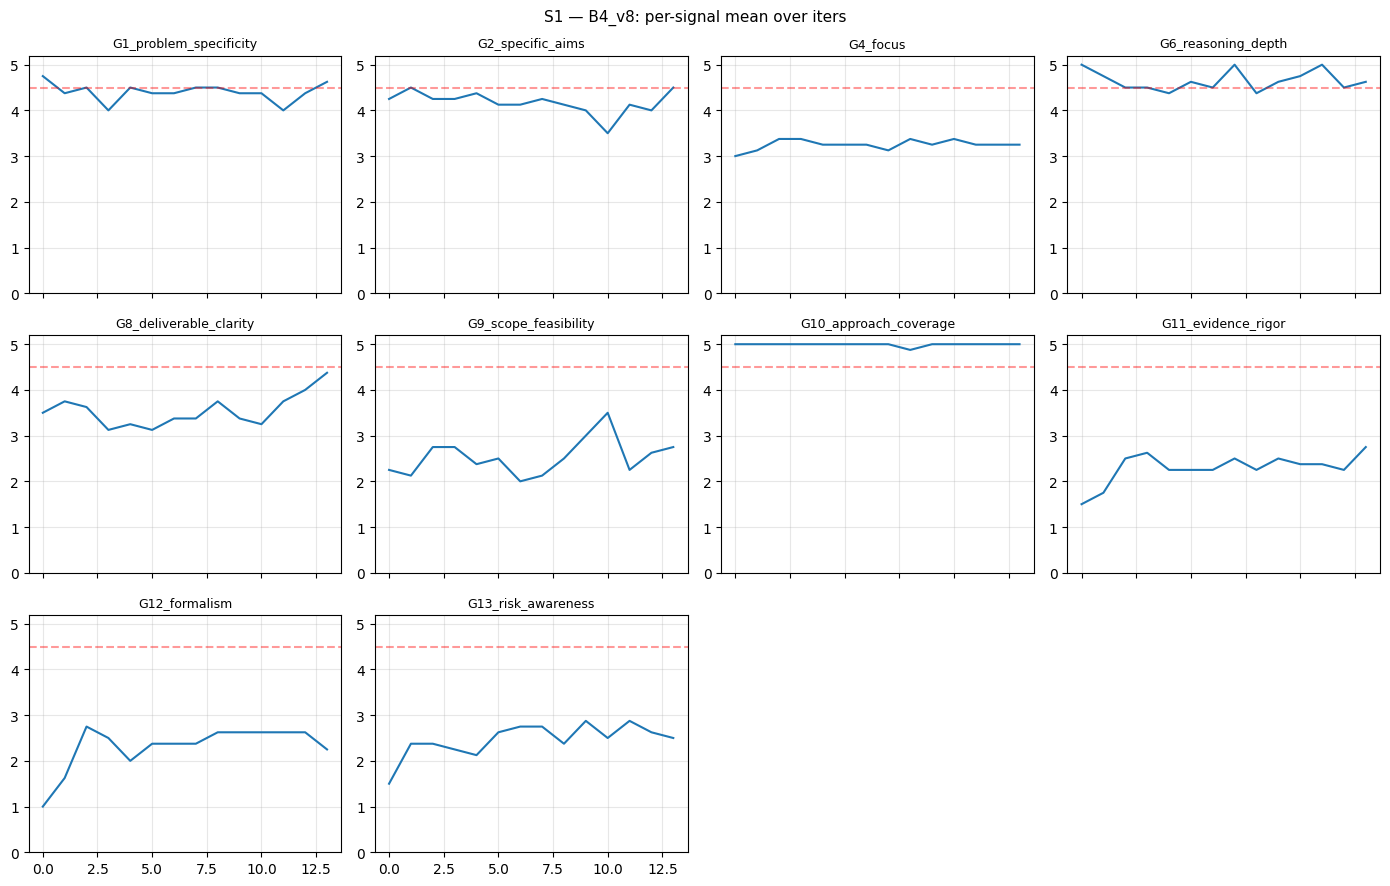

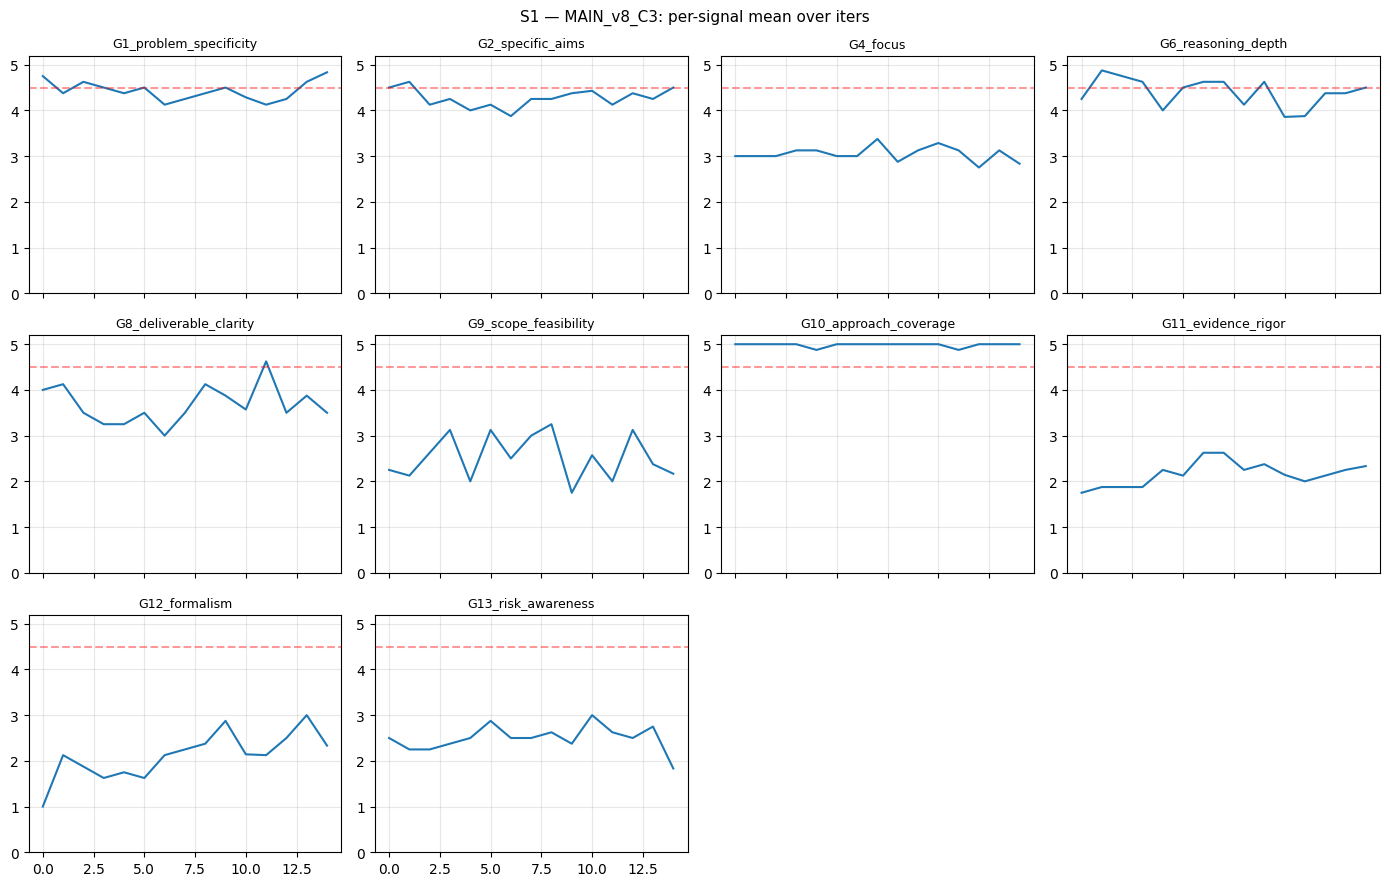

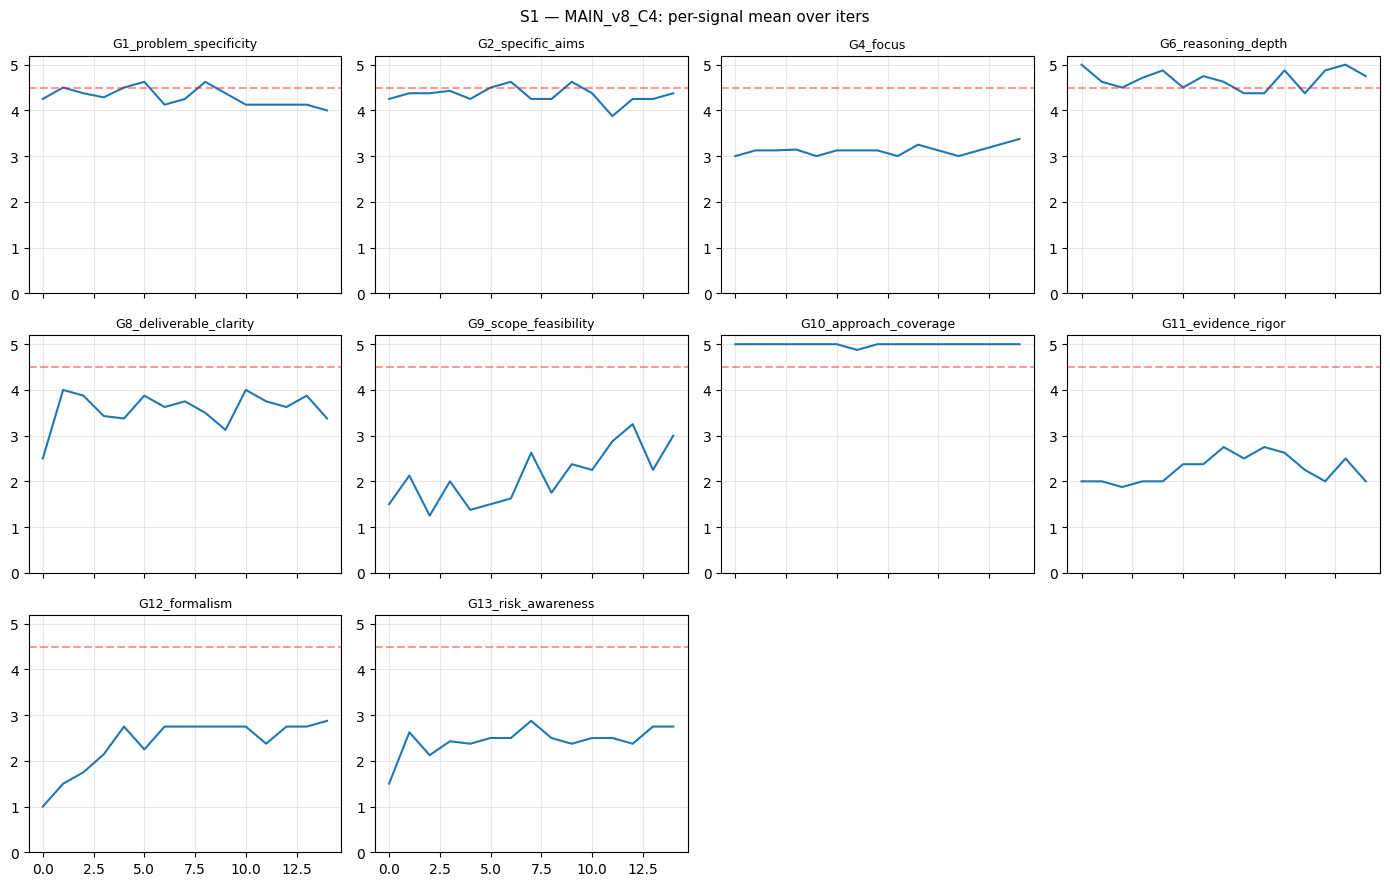

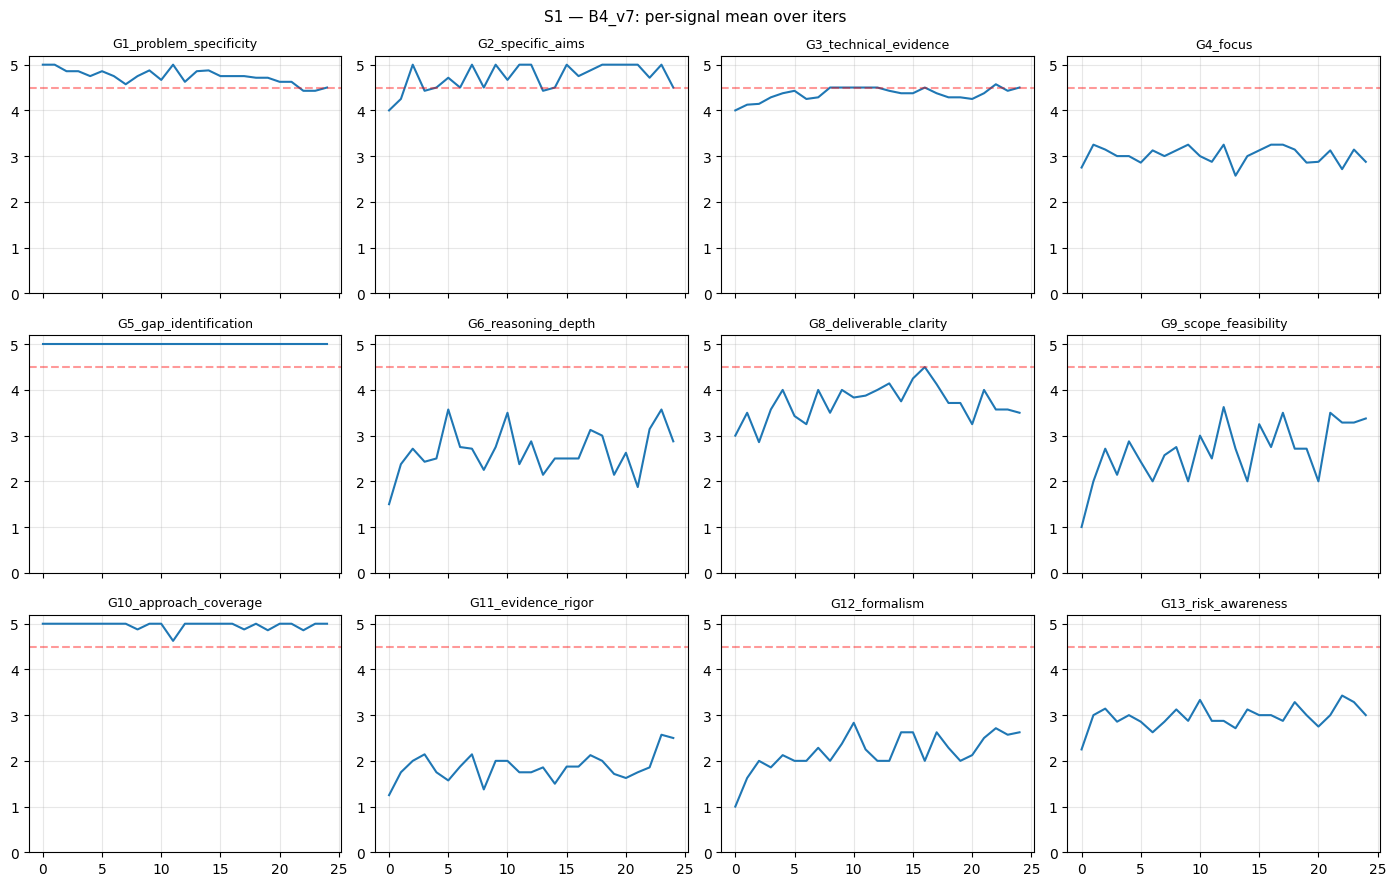

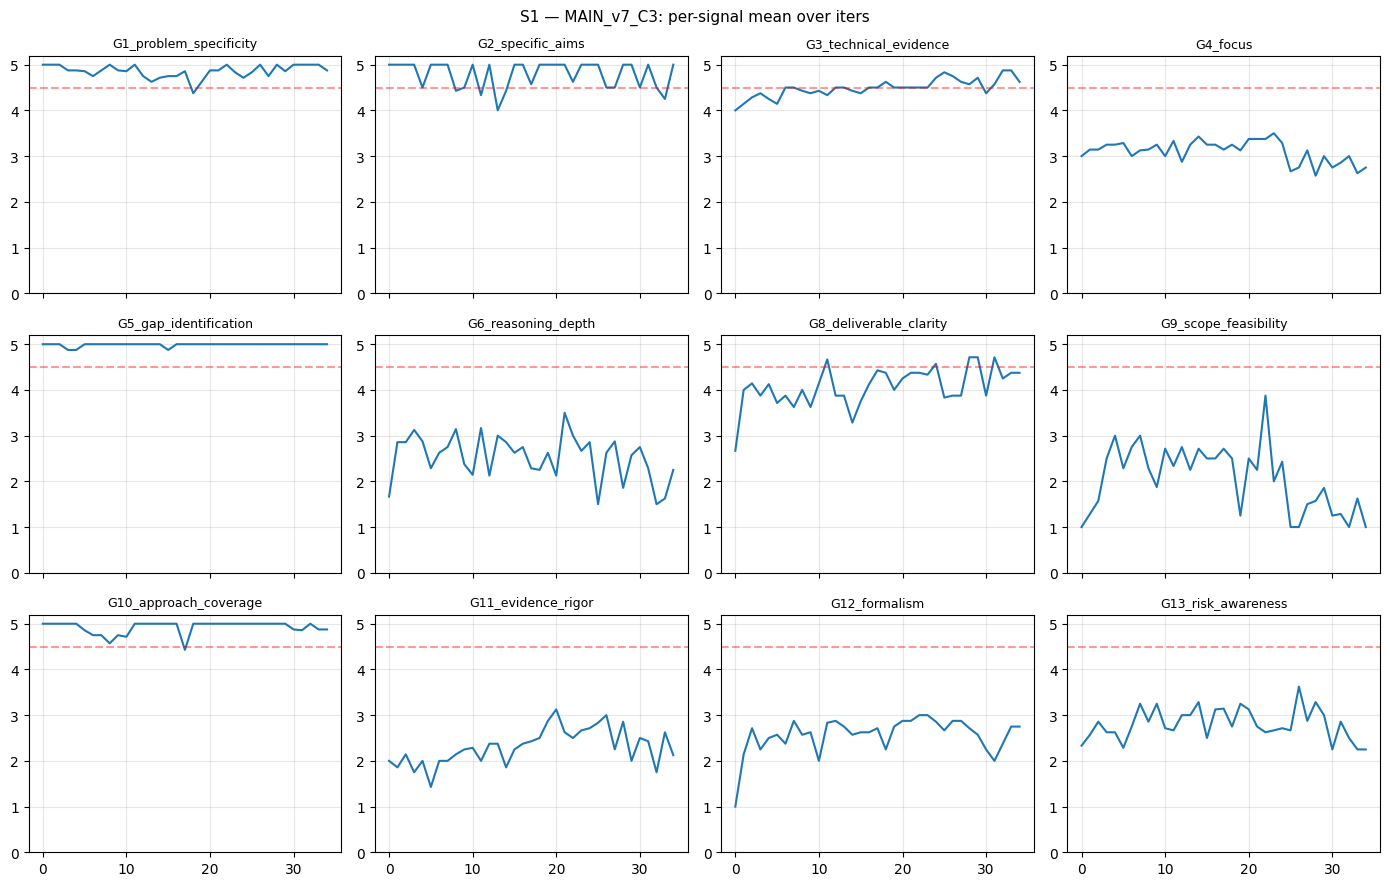

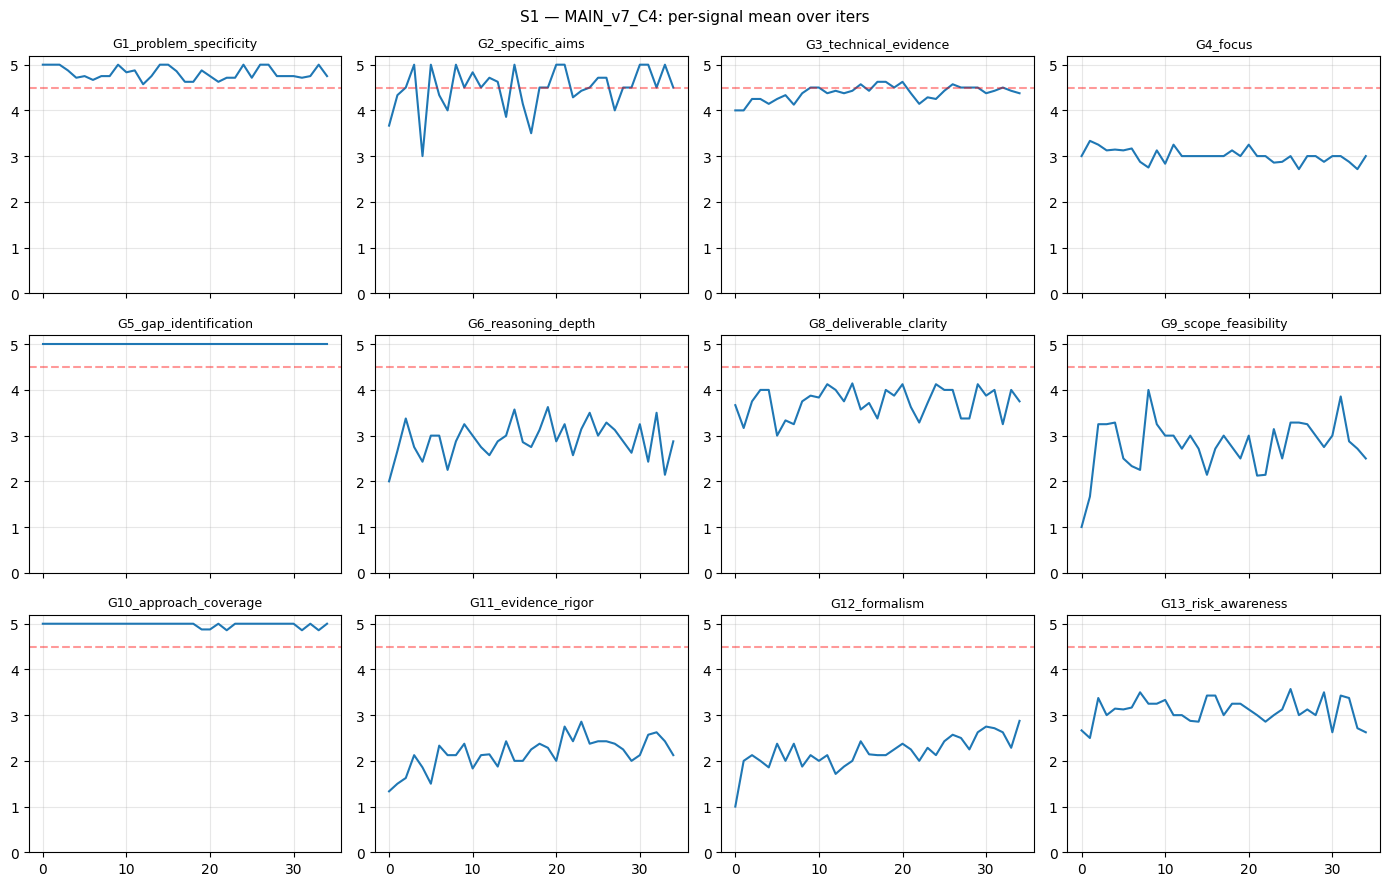


S1 summary:


,max_sig_mean,saturated_sigs,sat_early_AND_agg_climbing
run,,,
B4_v8,5.000,4,True
MAIN_v8_C3,5.000,5,False
MAIN_v8_C4,5.000,4,True
B4_v7,5.000,6,True
MAIN_v7_C3,5.000,6,False
MAIN_v7_C4,5.000,5,True


S1 verdict: {'B4_v8': True, 'MAIN_v8_C3': False, 'MAIN_v8_C4': True, 'B4_v7': True, 'MAIN_v7_C3': False, 'MAIN_v7_C4': True}


In [11]:
# S1. Per-signal mean over iters — grid subplot per run.
for name, info in dfs.items():
    df = info['df']
    if df.empty: continue
    sig_cols = [c for c in df.columns if c.startswith('sig_')]
    if not sig_cols: continue
    per_iter = df.groupby('iteration')[sig_cols].mean()
    n_sigs = len(sig_cols)
    ncols = 4; nrows = (n_sigs + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3 * nrows), sharex=True)
    axes = axes.ravel() if n_sigs > 1 else [axes]
    for i, col in enumerate(sig_cols):
        ax = axes[i]; ax.plot(per_iter.index, per_iter[col].values)
        ax.axhline(4.5, color='red', linestyle='--', alpha=0.4, label='sat threshold')
        ax.set_title(col.replace('sig_', ''), fontsize=9); ax.set_ylim(0, 5.2); ax.grid(alpha=0.3)
    for j in range(i + 1, len(axes)): axes[j].axis('off')
    fig.suptitle(f'S1 — {name}: per-signal mean over iters', fontsize=11)
    plt.tight_layout(); plt.show()

s1_rows = []
for name, info in dfs.items():
    df = info['df']
    if df.empty: continue
    sig_cols = [c for c in df.columns if c.startswith('sig_')]
    per_iter = df.groupby('iteration')[sig_cols].mean()
    agg_per_iter = df.groupby('iteration')['aggregate_reward'].mean()
    max_mean = per_iter.max().max(); sat_sigs = per_iter.max()[per_iter.max() >= 4.5].index.tolist()
    saturated_early = any(per_iter[sc].iloc[:min(20, len(per_iter))].max() >= 4.5 for sc in sig_cols)
    agg_still_climbing = (agg_per_iter.iloc[-5:].mean() - agg_per_iter.iloc[:5].mean()) > 0.02 if len(agg_per_iter) >= 10 else False
    s1_rows.append({'run': name, 'max_sig_mean': max_mean, 'saturated_sigs': len(sat_sigs),
                    'sat_early_AND_agg_climbing': saturated_early and agg_still_climbing})
s1 = pd.DataFrame(s1_rows).set_index('run')
print('\nS1 summary:'); display(s1)
s1_verdict = {r: row['sat_early_AND_agg_climbing'] for r, row in s1.iterrows()}
print('S1 verdict:', s1_verdict)

In [12]:
# S2. Intra-iter variance collapse at final iter.
s2_rows = []
for name, info in dfs.items():
    df = info['df']
    if df.empty: continue
    sig_cols = [c for c in df.columns if c.startswith('sig_')]
    final_it = df['iteration'].max()
    final_df = df[df['iteration'] == final_it]
    if len(final_df) < 3:
        s2_rows.append({'run': name, 'n_final': len(final_df), 'n_low_var_sigs': None}); continue
    variances = {c.replace('sig_', ''): float(final_df[c].var(ddof=0)) for c in sig_cols if final_df[c].notna().sum() >= 2}
    low_var = [k for k, v in variances.items() if v < 0.25]
    s2_rows.append({'run': name, 'n_final': len(final_df), 'n_low_var_sigs': len(low_var),
                    'low_var_sigs': ', '.join(low_var[:5])})
s2 = pd.DataFrame(s2_rows).set_index('run')
print('S2 — signals with var < 0.25 at final iter (dead gradient channels):')
display(s2)
s2_verdict = {r: (row['n_low_var_sigs'] >= 2) if pd.notna(row['n_low_var_sigs']) else None for r, row in s2.iterrows()}
print('S2 verdict:', s2_verdict)

S2 — signals with var < 0.25 at final iter (dead gradient channels):


,n_final,n_low_var_sigs,low_var_sigs
run,,,
B4_v8,8,2,"G4_focus, G10_approach_coverage"
MAIN_v8_C3,8,3,"G1_problem_specificity, G4_focus, G10_approach..."
MAIN_v8_C4,8,3,"G4_focus, G6_reasoning_depth, G10_approach_cov..."
B4_v7,8,3,"G4_focus, G5_gap_identification, G10_approach_..."
MAIN_v7_C3,8,7,"G1_problem_specificity, G2_specific_aims, G3_t..."
MAIN_v7_C4,8,4,"G1_problem_specificity, G3_technical_evidence,..."


S2 verdict: {'B4_v8': True, 'MAIN_v8_C3': True, 'MAIN_v8_C4': True, 'B4_v7': True, 'MAIN_v7_C3': True, 'MAIN_v7_C4': True}


In [13]:
# S3. Clip counterfactual — recompute aggregate with cap at 4.
s3_rows = []
for name, info in dfs.items():
    df = info['df']; weights = info['weights']
    if df.empty: continue
    final_it = df['iteration'].max()
    final_df = df[df['iteration'] == final_it].copy()
    if len(final_df) < 3:
        s3_rows.append({'run': name, 'n': len(final_df), 'rho_clip_unclip': None}); continue
    def reagg(row, clip):
        sv = {sid: row.get(f'sig_{sid}') for sid in weights}
        return aggregate_with_weights(sv, weights, clip_at=clip)
    final_df['unclipped'] = final_df.apply(lambda r: reagg(r, None), axis=1)
    final_df['clipped'] = final_df.apply(lambda r: reagg(r, 4), axis=1)
    if final_df['unclipped'].std() < 1e-6 or final_df['clipped'].std() < 1e-6:
        rho_cu = None
    else:
        rho_cu, _ = spearmanr(final_df['unclipped'], final_df['clipped'])
    s3_rows.append({'run': name, 'n': len(final_df), 'rho_clip_unclip': rho_cu})
s3 = pd.DataFrame(s3_rows).set_index('run')
print('S3 — Spearman ρ(clipped≤4, unclipped) at final iter:')
display(s3)
s3_verdict = {r: (row['rho_clip_unclip'] < 0.7) if pd.notna(row['rho_clip_unclip']) else None for r, row in s3.iterrows()}
print('S3 verdict:', s3_verdict)

S3 — Spearman ρ(clipped≤4, unclipped) at final iter:


,n,rho_clip_unclip
run,,
B4_v8,8,0.958
MAIN_v8_C3,8,NaN
MAIN_v8_C4,8,1.000
B4_v7,8,0.976
MAIN_v7_C3,8,0.945
MAIN_v7_C4,8,0.976


S3 verdict: {'B4_v8': np.False_, 'MAIN_v8_C3': None, 'MAIN_v8_C4': np.False_, 'B4_v7': np.False_, 'MAIN_v7_C3': np.False_, 'MAIN_v7_C4': np.False_}


In [14]:
# S4. Leave-one-signal-out ablation on final-iter plans.
s4_rows = []
for name, info in dfs.items():
    df = info['df']; weights = info['weights']
    if df.empty: continue
    final_it = df['iteration'].max()
    final_df = df[df['iteration'] == final_it]
    if len(final_df) < 3:
        s4_rows.append({'run': name, 'n': len(final_df), 'max_share': None, 'load_bearing_sig': None}); continue
    agg_full = final_df.apply(lambda r: aggregate_with_weights({s: r.get(f'sig_{s}') for s in weights}, weights), axis=1)
    shares = {}
    for drop_sig in weights:
        w_drop = {k: v for k, v in weights.items() if k != drop_sig}
        norm = sum(w_drop.values())
        w_norm = {k: v / norm for k, v in w_drop.items()}
        agg_lo = final_df.apply(lambda r: aggregate_with_weights({s: r.get(f'sig_{s}') for s in w_norm}, w_norm), axis=1)
        delta = (agg_full - agg_lo).abs()
        shares[drop_sig] = float(delta.median() / max(agg_full.median(), 1e-6))
    max_sig, max_share = max(shares.items(), key=lambda kv: kv[1])
    s4_rows.append({'run': name, 'n': len(final_df), 'max_share': max_share, 'load_bearing_sig': max_sig})
s4 = pd.DataFrame(s4_rows).set_index('run')
print('S4 — load-bearing signal (largest share of aggregate when removed):')
display(s4)
s4_verdict = {r: (row['max_share'] > 0.4) if pd.notna(row['max_share']) else None for r, row in s4.iterrows()}
print('S4 verdict:', s4_verdict)

S4 — load-bearing signal (largest share of aggregate when removed):


,n,max_share,load_bearing_sig
run,,,
B4_v8,8,0.095,G9_scope_feasibility
MAIN_v8_C3,8,0.224,G6_reasoning_depth
MAIN_v8_C4,8,0.131,G6_reasoning_depth
B4_v7,8,0.065,G12_formalism
MAIN_v7_C3,8,0.124,G6_reasoning_depth
MAIN_v7_C4,8,0.088,G12_formalism


S4 verdict: {'B4_v8': False, 'MAIN_v8_C3': False, 'MAIN_v8_C4': False, 'B4_v7': False, 'MAIN_v7_C3': False, 'MAIN_v7_C4': False}


In [15]:
# S5. Signal-to-length correlation — does a saturated signal correlate with length?
s5_rows = []
for name, info in dfs.items():
    df = info['df']; weights = info['weights']
    if df.empty or df['word_count'].isna().all(): continue
    mask = df['word_count'].notna()
    row = {'run': name}
    max_abs_rho = 0; max_sig = None
    for sid in weights:
        col = f'sig_{sid}'
        if col not in df.columns: continue
        m2 = mask & df[col].notna()
        if m2.sum() < 10: continue
        rho, _ = spearmanr(df.loc[m2, 'word_count'], df.loc[m2, col])
        if abs(rho) > abs(max_abs_rho): max_abs_rho = rho; max_sig = sid
    row['max_len_corr_sig'] = max_sig; row['max_len_corr_rho'] = max_abs_rho
    s5_rows.append(row)
s5 = pd.DataFrame(s5_rows).set_index('run')
print('S5 — signal most correlated with length (hints at length-via-signal hacking):')
display(s5)
s5_verdict = {r: (abs(row['max_len_corr_rho']) > 0.5) if pd.notna(row.get('max_len_corr_rho')) else None for r, row in s5.iterrows()}
print('S5 verdict:', s5_verdict)

S5 — signal most correlated with length (hints at length-via-signal hacking):


/tmp/ipykernel_363642/4277491348.py:14: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(df.loc[m2, 'word_count'], df.loc[m2, col])


,max_len_corr_sig,max_len_corr_rho
run,,
B4_v8,G12_formalism,0.778
MAIN_v8_C3,G12_formalism,0.779
MAIN_v8_C4,G12_formalism,0.819
B4_v7,G12_formalism,0.798
MAIN_v7_C3,G3_technical_evidence,0.646
MAIN_v7_C4,G13_risk_awareness,0.762


S5 verdict: {'B4_v8': True, 'MAIN_v8_C3': True, 'MAIN_v8_C4': True, 'B4_v7': True, 'MAIN_v7_C3': True, 'MAIN_v7_C4': True}


## Verdict Table

Consolidated one-page summary. ✅ = attack surface confirmed by this experiment. ❌ = not confirmed. `—` = insufficient data (usually missing Opus audits).

In [16]:
def mark(v):
    if v is None or (isinstance(v, float) and np.isnan(v)): return '—'
    return '✅' if v else '❌'

verdicts = {
    ('Length', 'L1 ρ(len,agg/sig)'): l1_verdict,
    ('Length', 'L2 length drift'): l2_verdict,
    ('Length', 'L3 ODIN R² gap'): l3_verdict,
    ('JudgeGap', 'J1 ρ drop'): j1_verdict,
    ('JudgeGap', 'J2 CI non-overlap'): j2_verdict,
    ('JudgeGap', 'J3 top-5 inv'): j3_verdict,
    ('Saturation', 'S1 mean sat'): s1_verdict,
    ('Saturation', 'S2 var collapse'): s2_verdict,
    ('Saturation', 'S3 clip rank'): s3_verdict,
    ('Saturation', 'S4 LOO share'): s4_verdict,
    ('Saturation', 'S5 sig~len'): s5_verdict,
}

runs_ordered = list(dfs.keys())
tbl_rows = []
for (surface, exp), v in verdicts.items():
    row = {'Attack Surface': surface, 'Experiment': exp}
    for r in runs_ordered: row[r] = mark(v.get(r))
    tbl_rows.append(row)

verdict_df = pd.DataFrame(tbl_rows).set_index(['Attack Surface', 'Experiment'])
print('=' * 80)
print('FINAL VERDICT TABLE')
print('=' * 80)
display(verdict_df)

# Per-surface overall verdict: attack surface is 'present' if ≥ 2 of its experiments confirm
print('\nPer-run overall verdict (attack surface present if ≥2 exps confirm):')
for r in runs_ordered:
    surf_counts = {}
    for (surface, exp), v in verdicts.items():
        surf_counts.setdefault(surface, []).append(v.get(r))
    print(f'  {r}:')
    for surface, vals in surf_counts.items():
        n_conf = sum(1 for x in vals if x is True)
        n_det = sum(1 for x in vals if x is not None)
        flag = '⚠️ PRESENT' if n_conf >= 2 else ('✓ clear' if n_det >= 2 else '— insufficient')
        print(f'    {surface:12s}: {n_conf}/{n_det} confirmed  {flag}')

FINAL VERDICT TABLE


B4_v8 MAIN_v8_C3 MAIN_v8_C4 B4_v7 MAIN_v7_C3  \
Attack Surface Experiment                                                       
Length         L1 ρ(len,agg/sig)     ✅          ✅          ✅     ✅          ✅   
               L2 length drift       ❌          ❌          ❌     ❌          ❌   
               L3 ODIN R² gap        —          —          —     —          —   
JudgeGap       J1 ρ drop             —          —          —     —          —   
               J2 CI non-overlap     —          —          —     —          —   
               J3 top-5 inv          —          —          —     —          —   
Saturation     S1 mean sat           ✅          ❌          ✅     ✅          ❌   
               S2 var collapse       ✅          ✅          ✅     ✅          ✅   
               S3 clip rank          ❌          —          ❌     ❌          ❌   
               S4 LOO share          ❌          ❌          ❌     ❌          ❌   
               S5 sig~len            ✅          ✅          ✅     ✅          ✅   

                                 MAIN_v7_C4  
Attack Surface Experiment                    
Length         L1 ρ(len,agg/sig)          ✅  
               L2 length drift            ❌  
               L3 ODIN R² gap             —  
JudgeGap       J1 ρ drop                  —  
               J2 CI non-overlap          —  
               J3 top-5 inv               —  
Saturation     S1 mean sat                ✅  
               S2 var collapse            ✅  
               S3 clip rank               ❌  
               S4 LOO share               ❌  
               S5 sig~len                 ✅


Per-run overall verdict (attack surface present if ≥2 exps confirm):
  B4_v8:
    Length      : 0/2 confirmed  ✓ clear
    JudgeGap    : 0/0 confirmed  — insufficient
    Saturation  : 3/5 confirmed  ⚠️ PRESENT
  MAIN_v8_C3:
    Length      : 0/2 confirmed  ✓ clear
    JudgeGap    : 0/0 confirmed  — insufficient
    Saturation  : 2/4 confirmed  ⚠️ PRESENT
  MAIN_v8_C4:
    Length      : 0/2 confirmed  ✓ clear
    JudgeGap    : 0/0 confirmed  — insufficient
    Saturation  : 3/5 confirmed  ⚠️ PRESENT
  B4_v7:
    Length      : 0/2 confirmed  ✓ clear
    JudgeGap    : 0/0 confirmed  — insufficient
    Saturation  : 3/5 confirmed  ⚠️ PRESENT
  MAIN_v7_C3:
    Length      : 0/2 confirmed  ✓ clear
    JudgeGap    : 0/0 confirmed  — insufficient
    Saturation  : 2/5 confirmed  ⚠️ PRESENT
  MAIN_v7_C4:
    Length      : 0/2 confirmed  ✓ clear
    JudgeGap    : 0/0 confirmed  — insufficient
    Saturation  : 3/5 confirmed  ⚠️ PRESENT


# Phase 0 Post-mortem Summary (2026-04-22 end of session)

## Data sources populated

| Suite | Status | Notes |
|---|---|---|
| L1 length-score ρ | ✅ 6/6 confirmed | v8 aggregate R² = 0.58 via ODIN fit (`odin_length_residual.json`), v7 = 0.53. G11/G12/G13 dominate. |
| L2 differential growth | ❌ 6/6 null | Length growth present everywhere but not MAIN-specific. |
| L3 ODIN R² gap | ⚠️ superseded by `odin_length_residual.py` | N=2-3 depth_audits/run too sparse. Full 1000+ buffer ODIN fit done outside notebook; see `analysis/odin_length_residual.json`. |
| J1-J3 judge gap | ⚠️ insufficient data | Same sparsity. Partial signal from today's pairwise eval (`v7_vs_v8_comparison.md`): all 6 runs iter 5 vs final, Opus prefers B (iter-final) in 5/6, TIE in v7 C4 (saturated). |
| S1 saturation | ✅ 4/6 confirmed | v8 B4+C4, v7 B4+C4 saturate; v7/v8 SDPO do not (has its own failure mode — hallucination hacking) |
| S2 variance collapse | ✅ 6/6 confirmed | Dead gradient channels at final iter across all runs |
| S3 clip counterfactual | mostly false | |
| S4 leave-one-out | false | Weight concentration not the issue |
| S5 dominant signal |  6/6 | |

## Cross-reference to other artifacts

- **ODIN full regression**: `analysis/odin_length_residual.json` + `odin_length_residual.py` — all 1000+ buffer entries, superset of L3
- **Pairwise substance eval** (iter 5 vs iter-final, length-blind): `analysis/v7_vs_v8_comparison.md` — three distinct failure modes: length hacking (v8), hallucination hacking (v7 C3 SDPO), buffer saturation (v7 C4 aggregate)
- **DECISIONS.md head entry**: summarizes v9 design queue

## What's still missing for rigorous J1-J3

Would need ≥6 Opus audits per run distributed across iters (early/mid/late) for bootstrap. Current data has 2-3 per v8 run, 1 per v7 run (via pairwise). Can be backfilled cheaply (~$3) if J/L tables become decision-critical.

## Bottom line

Length bias is confirmed as the dominant attack surface. Weight concentration, grader family, and RL algorithm are NOT the main driver. v9 needs count-based G11/G12/G13 + exploration diversity fixes (see `DECISIONS.md` head).